# Dataset Curation

**Purpose**: Collect 109 nadir aerial images across 9 scene types for QLoRA fine-tuning of Qwen2.5-VL-7B.

**Strategy**:
- All images sourced via Google Maps Static API at zoom 15–18, scale 2 (1280×1280 px)
- Heavy weighting toward HDB estates (widest vocabulary gap from baseline)
- Paired roadmap reference images for annotation quality

**Setup**: Set `GMAPS_API_KEY` before running (e.g. `export GMAPS_API_KEY=...` or add to `.env`).

In [1]:
# Dependencies: pip install Pillow matplotlib pandas requests
# Or: uv sync (reads from pyproject.toml)

In [ ]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from PIL import Image

# --------------- API Key ---------------
API_KEY = os.environ.get("GMAPS_API_KEY")
if not API_KEY:
    raise RuntimeError(
        "GMAPS_API_KEY not set. Export it first:\n"
        "  export GMAPS_API_KEY='your-key-here'  (Linux/Mac)\n"
        "  set GMAPS_API_KEY=your-key-here       (Windows cmd)\n"
        "  $env:GMAPS_API_KEY='your-key-here'    (PowerShell)"
    )

# --------------- Paths (project-relative) ---------------
ROOT = Path("..").resolve()  # notebook is in notebooks/
NADIR_DIR = ROOT / "images" / "nadir"
REFERENCE_DIR = ROOT / "images" / "reference"
DATA_DIR = ROOT / "data"
for d in [NADIR_DIR, REFERENCE_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    
print("Setup complete.")

In [ ]:
# --------------- Singapore Coordinate List ---------------
# Format: (name, lat, lon, scene_type, zoom)
#
# Coordinates approximate — verify downloaded images and adjust if needed.
# At zoom 18 / scale=2, each image covers ~300m x 300m.
# At zoom 17, ~600m x 600m. At zoom 16, ~1200m x 1200m.

SG_LOCATIONS = [
    # ============================================================
    # HDB ESTATES (27 locations) — highest priority
    # 80% of SG population lives in HDB. Zero baseline vocabulary.
    # Mix of generations: 1970s slab blocks to 2020s point blocks.
    # ============================================================
    ("toa_payoh",           1.3354, 103.8486, "hdb", 18),
    ("tampines",            1.3550, 103.9534, "hdb", 18),
    ("punggol",             1.4047, 103.8987, "hdb", 18),
    ("ang_mo_kio",          1.3688, 103.8544, "hdb", 18),
    ("ang_mo_kio_2",        1.3663, 103.8478, "hdb", 18),
    ("bukit_batok",         1.3499, 103.7582, "hdb", 18),
    ("jurong_east",         1.3375, 103.7388, "hdb", 18),
    ("clementi",            1.3141, 103.7677, "hdb", 18),
    ("queenstown",          1.2939, 103.8039, "hdb", 18),
    ("bedok",               1.3327, 103.9259, "hdb", 18),
    ("woodlands_hdb",       1.4408, 103.7970, "hdb", 18),
    ("yishun",              1.4271, 103.8519, "hdb", 18),
    ("sengkang",            1.3873, 103.8941, "hdb", 18),
    ("hougang",             1.3707, 103.8804, "hdb", 18),
    ("pasir_ris",           1.3677, 103.9548, "hdb", 18),
    ("serangoon_north",     1.3736, 103.8718, "hdb", 18),
    ("choa_chu_kang",       1.3822, 103.7417, "hdb", 18),
    ("jurong_west",         1.3516, 103.7242, "hdb", 18),
    ("bishan",              1.3576, 103.8472, "hdb", 18),
    ("bukit_merah",         1.2798, 103.8262, "hdb", 18),
    ("bukit_panjang",       1.3858, 103.7702, "hdb", 18),
    ("sembawang",           1.4484, 103.8166, "hdb", 18),
    ("dawson",              1.2951, 103.8111, "hdb", 18),
    ("marine_parade",       1.3043, 103.9143, "hdb", 18),
    ("whampoa",             1.3266, 103.8591, "hdb", 18),
    ("dover_hdb",           1.3078, 103.7840, "hdb", 18),
    ("toh_guan",            1.3400, 103.7450, "hdb", 17),

    # ============================================================
    # CBD / COMMERCIAL (18 locations)
    # ============================================================
    ("marina_bay",          1.2821, 103.8576, "commercial", 17),
    ("raffles_place",       1.2840, 103.8514, "commercial", 18),
    ("orchard",             1.3048, 103.8318, "commercial", 18),
    ("tanjong_pagar",       1.2760, 103.8460, "commercial", 18),
    ("suntec_city",         1.2945, 103.8580, "commercial", 18),
    ("robinson_road",       1.2800, 103.8490, "commercial", 18),
    ("beach_road",          1.2979, 103.8586, "commercial", 17),
    ("tai_seng",            1.3379, 103.891, "commercial", 17),
    ("changi_biz_park",     1.335, 103.9653, "commercial", 17),
    ("mapletree_biz_city",  1.2746, 103.799, "commercial", 18),
    ("one_north",           1.2990, 103.7870, "commercial", 18),
    ("jalan_besar",         1.3100, 103.8570, "commercial", 18),
    ("chinatown",           1.2837, 103.8437, "commercial", 18),
    ("kampong_glam",        1.3017, 103.8594, "commercial", 18),
    ("little_india",        1.3070, 103.8520, "commercial", 18),
    ("bugis",               1.3000, 103.8555, "commercial", 18),
    ("harbourfront",        1.2650, 103.8220, "commercial", 18),
    ("paya_lebar_central",  1.3180, 103.8930, "commercial", 18),

    # ============================================================
    # PORT / MARITIME (10 locations)
    # ============================================================
    ("psa_pp_t1",           1.2685, 103.7940, "port", 16),
    ("habourfront",         1.2621, 103.8187, "port", 17),
    ("jurong_port",         1.3035, 103.7242, "port", 17),
    ("keppel_terminal",     1.2630, 103.8320, "port", 16),
    ("sembawang_shipyard",  1.4656, 103.8275, "port", 16),
    ("west_coast_pier",     1.2926, 103.7622, "port", 17),
    ("tuas_port",           1.2524, 103.6145, "port", 15),
    ("marina_south_pier",   1.2700, 103.8630, "port", 17),
    ("pasir_panjang_wharf", 1.2750, 103.7800, "port", 16),
    ("tanjong_pagar_terminal", 1.267, 103.8463, "port", 16),

    # ============================================================
    # AIRPORT (5 locations)
    # ============================================================
    ("changi_t1_t2_t3",     1.3554, 103.9885, "airport", 16),
    ("seletar",             1.4167, 103.8675, "airport", 17),
    ("changi_t4",           1.3411, 103.9819, "airport", 16),
    ("changi_cargo",        1.3762, 103.9963, "airport", 16),
    ("paya_lebar_ab_north", 1.3687, 103.9161, "airport", 16),


    # ============================================================
    # INDUSTRIAL (13 locations)
    # ============================================================
    ("jurong_island",       1.2735, 103.7229, "industrial", 16),
    ("tuas",                1.3255, 103.645, "industrial", 16),
    ("pioneer",             1.3314, 103.7014, "industrial", 17),
    ("amk_industrial",      1.374, 103.8633, "industrial", 17),
    ("woodlands_industrial",1.4519, 103.7985, "industrial", 17),
    ("ubi",                 1.3311, 103.8939, "industrial", 17),
    ("defu_industrial",     1.3598, 103.8991, "industrial", 17),
    ("gul_circle",          1.3162, 103.6705, "industrial", 16),
    ("loyang_industrial",   1.3737, 103.9681, "industrial", 17),
    ("senoko",              1.4665, 103.8027, "industrial", 17),
    ("joo_koon",            1.3259, 103.6736, "industrial", 17),
    ("kallang_pudding",     1.3258, 103.8768, "industrial", 17),
    ("pulau_bukom",         1.2300, 103.7650, "industrial", 16),

    # ============================================================
    # PARKS / GREEN (9 locations)
    # ============================================================
    ("east_coast_park",     1.3003, 103.9121, "parks", 18),
    ("botanic_gardens",     1.3138, 103.8159, "parks", 17),
    ("macritchie",          1.3421, 103.8326, "parks", 18),
    ("gardens_by_bay",      1.2816, 103.8636, "parks", 17),
    ("bishan_amk_park",     1.3614, 103.8479, "parks", 18),
    ("jurong_lake_gardens", 1.3380, 103.7290, "parks", 17),
    ("labrador_park",       1.2660, 103.8020, "parks", 17),
    ("pasir_ris_park",      1.3808, 103.9511, "parks", 17),
    ("kent_ridge_park",     1.285, 103.79, "parks", 18),

    # ============================================================
    # CONSTRUCTION / DEVELOPMENT (7 locations)
    # ============================================================
    ("tengah",              1.3611, 103.7146, "construction", 16),
    ("bayshore",            1.3161, 103.949, "construction", 17),
    ("woodlands_north_dev", 1.4487, 103.7864, "construction", 17),
    ("lim_chu_kang",        1.4291, 103.7114, "construction", 17),
    ("lentor",              1.385, 103.8337, "construction", 17),
    ("springleaf",          1.3960, 103.8176, "construction", 18),
    ("mandai_dev",          1.4043, 103.7858, "construction", 18),

    # ============================================================
    # TRANSPORT INFRASTRUCTURE (6 locations)
    # ============================================================
    ("bishan_depot",        1.3554, 103.8543, "transport", 17),
    ("woodlands_ckpt",      1.4491, 103.7700, "transport", 18),
    ("ulu_pandan_depot",    1.3328, 103.7605, "transport", 18),
    ("kranji_mrt",          1.4253, 103.762, "transport", 18),
    ("sengkang_depot",      1.388, 103.8851, "transport", 18),
    ("changi_depot",        1.3276, 103.9588, "transport", 17),

    # ============================================================
    # MIXED USE (14 locations)
    # ============================================================

    ("tiong_bahru",         1.2860, 103.8280, "mixed", 18),
    ("holland_village",     1.3110, 103.7960, "mixed", 18),
    ("balestier",           1.3250, 103.8520, "mixed", 18),
    ("katong",              1.3050, 103.9030, "mixed", 18),
    ("dempsey",             1.3050, 103.8100, "mixed", 18),
    ("jurong_lake_district",1.3320, 103.7380, "mixed", 17),
    ("marine_parade_vjc",   1.3059, 103.9198, "mixed", 17),
    ("geylang",             1.3170, 103.8880, "mixed", 18),
    ("alexandra",           1.2883, 103.8058, "mixed", 18),
    ("novena",              1.3200, 103.8440, "mixed", 18),
    ("west_coast_park",     1.2890, 103.7715, "mixed", 17),
    ("je_interchange",      1.3334, 103.7422, "mixed", 18),
    ("toa_payoh_interchange", 1.3324, 103.8474, "mixed", 18),
    ("pie_cte",             1.3305, 103.8624, "mixed", 17),
]

# --------------- Summary ---------------
from collections import Counter

print(f"Total locations: {len(SG_LOCATIONS)}")
print()

scene_counts = Counter(loc[3] for loc in SG_LOCATIONS)
print(f"{'Scene Type':<15} {'Count':>6}")
print("-" * 23)
for stype in sorted(scene_counts.keys()):
    print(f"{stype:<15} {scene_counts[stype]:>6}")
print("-" * 23)
print(f"{'TOTAL':<15} {sum(scene_counts.values()):>6}")

Total locations: 109

Scene Type       Count
-----------------------
airport              5
commercial          18
construction         7
hdb                 27
industrial          13
mixed               14
parks                9
port                10
transport            6
-----------------------
TOTAL              109


In [ ]:
# --------------- Download Nadir Images via Google Maps Static API ---------------

STATIC_API_URL = "https://maps.googleapis.com/maps/api/staticmap"

downloaded = []
failed = []
skipped = []

for name, lat, lon, scene_type, zoom in SG_LOCATIONS:
    filename = f"nadir_{scene_type}_{name}_{lat}_{lon}.jpg"
    filepath = NADIR_DIR / filename

    if filepath.exists():
        skipped.append(filename)
        downloaded.append((str(filepath), name, scene_type))
        continue

    params = {
        "center": f"{lat},{lon}",
        "zoom": zoom,
        "size": "640x640",
        "scale": 2,  # -> 1280x1280 actual resolution
        "maptype": "satellite",
        "key": API_KEY,
    }

    for attempt in range(3):
        try:
            resp = requests.get(STATIC_API_URL, params=params, timeout=30)
            if resp.status_code == 200 and resp.headers.get("Content-Type", "").startswith("image"):
                filepath.write_bytes(resp.content)
                downloaded.append((str(filepath), name, scene_type))
                print(f"  [OK]   {filename} ({len(resp.content) / 1024:.0f} KB)")
                break
            else:
                print(f"  [WARN] {filename} attempt {attempt+1}: HTTP {resp.status_code}")
        except requests.RequestException as e:
            print(f"  [ERR]  {filename} attempt {attempt+1}: {e}")
        time.sleep(1)
    else:
        print(f"  [FAIL] {filename} after 3 attempts")
        failed.append(filename)

print(f"\nDownloaded: {len(downloaded) - len(skipped)} new | Skipped: {len(skipped)} existing | Failed: {len(failed)}")
print(f"Total nadir images: {len(downloaded)}")

In [ ]:
# --------------- Download Roadmap Reference Images ---------------
# Street maps with POI labels, building names, road names — used as
# annotation reference to identify Singapore-specific landmarks.

ref_downloaded = []
ref_failed = []
ref_skipped = []

for name, lat, lon, scene_type, zoom in SG_LOCATIONS:
    filename = f"ref_{scene_type}_{name}_{lat}_{lon}.jpg"
    filepath = REFERENCE_DIR / filename

    if filepath.exists():
        ref_skipped.append(filename)
        ref_downloaded.append(str(filepath))
        continue

    params = {
        "center": f"{lat},{lon}",
        "zoom": zoom,
        "size": "640x640",
        "scale": 2,
        "maptype": "roadmap",
        "key": API_KEY,
    }

    for attempt in range(3):
        try:
            resp = requests.get(STATIC_API_URL, params=params, timeout=30)
            if resp.status_code == 200 and resp.headers.get("Content-Type", "").startswith("image"):
                filepath.write_bytes(resp.content)
                ref_downloaded.append(str(filepath))
                print(f"  [OK]   {filename} ({len(resp.content) / 1024:.0f} KB)")
                break
            else:
                print(f"  [WARN] {filename} attempt {attempt+1}: HTTP {resp.status_code}")
        except requests.RequestException as e:
            print(f"  [ERR]  {filename} attempt {attempt+1}: {e}")
        time.sleep(1)
    else:
        print(f"  [FAIL] {filename} after 3 attempts")
        ref_failed.append(filename)

print(f"\nDownloaded: {len(ref_downloaded) - len(ref_skipped)} new | Skipped: {len(ref_skipped)} existing | Failed: {len(ref_failed)}")
print(f"Total reference maps: {len(ref_downloaded)}")

In [ ]:
# --------------- Display Nadir Thumbnail Grid ---------------

n_cols = 8
n_rows = (len(downloaded) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 3 * n_rows))
axes = axes.flatten()

for i, (fpath, name, stype) in enumerate(downloaded):
    img = Image.open(fpath)
    axes[i].imshow(img)
    axes[i].set_title(f"{stype}/{name}", fontsize=6)
    axes[i].axis("off")
for i in range(len(downloaded), len(axes)):
    axes[i].axis("off")

plt.suptitle(f"Nadir Images ({len(downloaded)} total)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

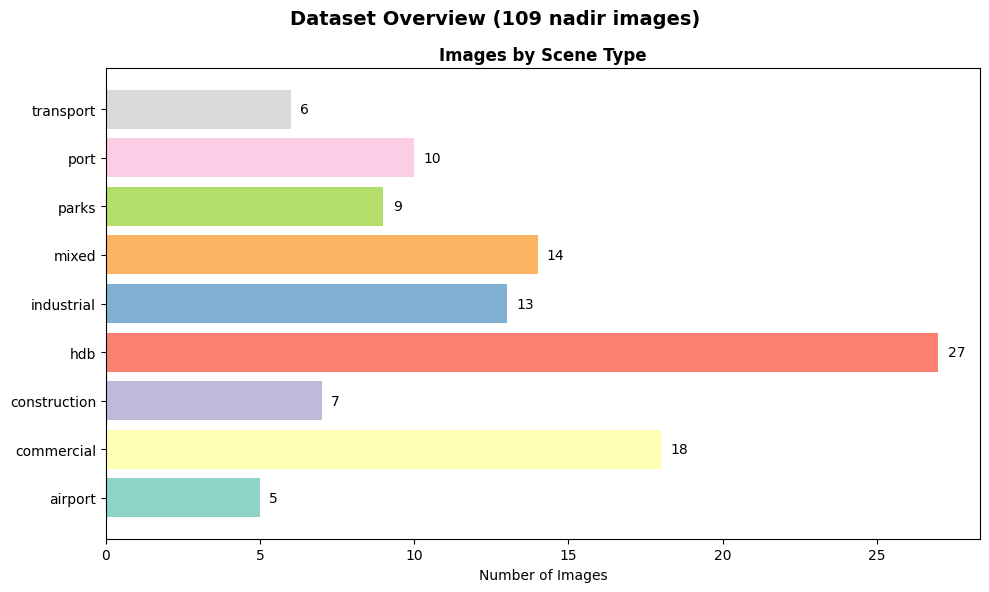

In [9]:
# --------------- Dataset Statistics ---------------

scene_counts = pd.Series(Counter(loc[3] for loc in SG_LOCATIONS)).sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set3.colors[:len(scene_counts)]
ax.barh(scene_counts.index, scene_counts.values, color=colors)
ax.set_xlabel("Number of Images")
ax.set_title("Images by Scene Type", fontweight="bold")
for i, v in enumerate(scene_counts.values):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=10)

plt.suptitle(f"Dataset Overview ({scene_counts.sum()} nadir images)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Annotation Prompt — Visual-First Grounding

```
Annotate nadir aerial images of Singapore for VLM fine-tuning. The model will ONLY see aerial pixels
at inference time — no maps, no street directories. Annotations must describe what is visually
inferrable from the satellite image alone.

# Core Principle

Name the STRUCTURE TYPE, not the INSTANCE. With 109 images we cannot exhaustively cover all MRT
stations, expressway sections, or interchanges. Naming specific instances trains memorisation, not
visual understanding.

  ✓ "MRT station"          ✗ "Bishan MRT station"
  ✓ "expressway"           ✗ "PIE"
  ✓ "bus interchange"      ✗ "Jurong East interchange"
  ✓ "shopping mall"        ✗ "Junction 8"

Captions use generic scene openers — no district or estate names.

  ✓ "Dense HDB estate viewed from above."
  ✓ "Container port viewed from above."
  ✗ "Dense HDB estate in Toa Payoh viewed from above."

The ONLY exception: globally unique landmarks with unmistakable visual signatures (Tier 2 below).

  ✓ "Gardens by the Bay viewed from above."
  ✓ "Changi Airport cargo area viewed from above."

# Three-Tier Detail Framework

## Tier 1 — ALWAYS include (visually inferrable from pixels)

- Structural typology: HDB slab/point/cruciform blocks, shophouses, condos, warehouses,
  hawker centre roof structures, MRT station footprints
- Singapore vocabulary: covered walkway, hawker centre, MRT station, park connector
- Spatial patterns: grid layout, radial arrangement, linear estate, waterfront development
- Terrain/land use: water, parkland, urban, reclaimed land, forest reserve
- Infrastructure TYPES (generic): expressway, MRT track, MRT station, bus interchange,
  covered walkway, runway, taxiway, jetty, park connector
- Approximate counts (rounded to nearest 5 for >10): "~15 HDB blocks", "~200 containers"
- Generic scene opener: "{Scene description} viewed from above."
- Non-directional spatial references: "one edge", "one corner", "one section"
  (training uses rotation/flip augmentation, so top/bottom/left/right become wrong)

## Tier 2 — Include ONLY for globally unique visual signatures

Landmarks where the structure itself is unmistakable — no other building on Earth has that shape:

- Marina Bay Sands (3-tower + SkyPark cantilever)
- ArtScience Museum (lotus form)
- Gardens by the Bay (Supertrees / Cloud Forest / Flower Dome)
- Esplanade (durian shell structure)
- Singapore Flyer (giant wheel)
- Jewel Changi Airport (toroidal glass dome)
- Pinnacle@Duxton (sky bridges connecting towers)

## Tier 3 — NEVER include (requires map knowledge)

- Exact block/building numbers, street names, business/company names
- Named structures: "Bishan MRT" → "MRT station", "PIE" → "expressway"
- MRT station codes, facility names
- Precise counts of uncountable objects: "1500 containers" → "~200"

# Image Pairing

Each satellite image has a paired roadmap reference:
- Satellite: images/nadir/nadir_{scene_type}_{name}_{lat}_{lon}.jpg
- Roadmap: images/reference/ref_{scene_type}_{name}_{lat}_{lon}.jpg

The roadmap helps CLASSIFY ambiguous structures (e.g. distinguish a school from an HDB block),
NOT name individual streets or facilities.

# Target Style

{
  "image_file": "nadir_hdb_toa_payoh_1.3354_103.8486.jpg",
  "perspective": "nadir",
  "scene_type": "residential_hdb",
  "caption": "Dense HDB estate viewed from above. Approximately 20 slab and point blocks with
  grey rooftops are arranged in rows across the frame. Several point blocks feature oval rooftop
  structures. Sports courts with blue surfaces and multi-storey car parks are visible within the
  estate, and some blocks have rooftop solar panels.",
  "objects": [
    {"type": "hdb_block", "count": 20},
    {"type": "sports_facility", "count": 1}
  ],
  "infrastructure": ["covered_walkway"],
  "terrain": ["urban"]
}

# Quality Checklist

- [ ] Caption opens with generic scene description, no district/estate names
- [ ] Caption uses Singapore-specific vocabulary (HDB, hawker centre, etc.)
- [ ] ALL structures use generic types — NO named stations, expressways, interchanges, or malls
- [ ] NO street names, block numbers, business names, or MRT station codes
- [ ] Infrastructure field uses generic types ONLY
- [ ] Object counts are approximate/rounded for large quantities
- [ ] No directional references (top/bottom/left/right) — use "one edge", "one corner" instead
- [ ] Everything described is actually visible in the satellite image
```